In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

import torch
import torchaudio
import torch.nn as nn
import torch.nn.init as init
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

from typing import Tuple, List
from tqdm.auto import tqdm, trange
from IPython.display import display, Audio

import librosa
import librosa.display

### UrbanSound8K

Мы будем работать с датасетом **UrbanSound8K**. В нём содержится 8732 размеченных аудиофрагмента городских звуков длительностью не более 4 секунд. В датасете 10 классов:
`air_conditioner`, `car_horn`, `children_playing`, `dog_bark`, `drilling`, `engine_idling`, `gun_shot`, `jackhammer`, `siren`, `street_music`.

Скачиваем UrbanSound8K отсюда https://urbansounddataset.weebly.com/urbansound8k.html

Структура датасета:
```
UrbanSound8K/
├── audio/
│   ├── fold1/
│   ├── fold2/
│   └── ...
└── metadata/
    └── UrbanSound8K.csv
```

**Важное замечание про протокол разбиения**

UrbanSound8K уже разбит авторами на 10 fold'ов, и в этой задаче нужно использовать именно их.

Для этого датасета не стоит делать случайное разбиение, потому что фрагменты, относящиеся к одному и тому же исходному событию, могут оказаться и в обучении, и в тесте. В таком случае качество будет завышено и перестанет честно отражать способность модели обобщать на новые данные.

Поэтому здесь используется следующая схема:

- для быстрых экспериментов: `folds 1–8 -> train`, `9 -> val`, `10 -> test`;
- для финальной оценки: один прогон 10-fold cross-validation по official folds.

Случайно перераспределять примеры между fold'ами не нужно.  
При этом `shuffle=True` внутри `train_loader` использовать можно.

In [2]:
DATASET_PATH = kagglehub.dataset_download("chrisfilo/urbansound8k")

print("Dataset path:", DATASET_PATH)
# Путь к metadata-файлу

metadata_path = os.path.join(DATASET_PATH, "UrbanSound8K.csv")
# Если не сработает, попробуем стандартную структуру

if not os.path.exists(metadata_path):
    metadata_path = os.path.join(DATASET_PATH, "metadata", "UrbanSound8K.csv")

# Загружаем метаданные
metadata = pd.read_csv(metadata_path)

print(f"Всего примеров: {len(metadata)}")
print("\nРаспределение по классам:")
print(metadata["class"].value_counts().sort_index())
print("\nРаспределение по fold'ам:")
print(metadata["fold"].value_counts().sort_index())

Dataset path: /Users/polzovatel/.cache/kagglehub/datasets/chrisfilo/urbansound8k/versions/1
Всего примеров: 8732

Распределение по классам:
class
air_conditioner     1000
car_horn             429
children_playing    1000
dog_bark            1000
drilling            1000
engine_idling       1000
gun_shot             374
jackhammer          1000
siren                929
street_music        1000
Name: count, dtype: int64

Распределение по fold'ам:
fold
1     873
2     888
3     925
4     990
5     936
6     823
7     838
8     806
9     816
10    837
Name: count, dtype: int64


## Расширенное EDA датасета UrbanSound8K

В этой части мы анализируем не саму модель, а данные, на которых она обучается. Это важно для проекта, потому что качество аудиоклассификации зависит не только от архитектуры CNN, но и от состава датасета, баланса классов, длительности фрагментов и корректного разбиения на fold'ы.

Основные вопросы EDA:

- сколько объектов и классов в датасете;
- есть ли пропуски и дубликаты;
- сбалансированы ли классы;
- равномерно ли классы распределены по fold'ам;
- какие длительности у аудиофрагментов;
- как выглядят waveform и mel-спектрограммы разных классов;
- какие потенциальные сложности это создает для модели.


In [3]:
# Общая информация о metadata

print("Размер metadata:", metadata.shape)
print("\nКолонки:")
print(metadata.columns.tolist())

display(metadata.head())

print("\nТипы данных:")
display(metadata.dtypes.to_frame("dtype"))

print("\nПропуски по колонкам:")
display(metadata.isna().sum().to_frame("missing_count"))

print("\nКоличество полных дубликатов:", metadata.duplicated().sum())
print("Количество дубликатов по имени файла:", metadata["slice_file_name"].duplicated().sum())


Размер metadata: (8732, 8)

Колонки:
['slice_file_name', 'fsID', 'start', 'end', 'salience', 'fold', 'classID', 'class']


,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing



Типы данных:


,dtype
slice_file_name,object
fsID,int64
start,float64
end,float64
salience,int64
fold,int64
classID,int64
class,object



Пропуски по колонкам:


,missing_count
slice_file_name,0
fsID,0
start,0
end,0
salience,0
fold,0
classID,0
class,0



Количество полных дубликатов: 0
Количество дубликатов по имени файла: 0


### Анализ признаков в metadata

В `UrbanSound8K.csv` есть не только название класса, но и вспомогательные поля:

- `slice_file_name` - имя аудиофайла;
- `fsID` - id исходной записи;
- `start`, `end` - границы фрагмента в исходной записи;
- `salience` - насколько звук является foreground/background;
- `fold` - номер официального fold'а;
- `classID`, `class` - числовая и текстовая метка класса.

Отдельно важно поле `fold`: его нельзя игнорировать, потому что авторы датасета уже подготовили корректное разбиение для оценки модели.


In [4]:
# Автоматически ищем папку, внутри которой лежат fold1, fold2, ..., fold10

audio_root = None

for root, dirs, files in os.walk(DATASET_PATH):
    dirs_set = set(dirs)
    
    if {"fold1", "fold2", "fold3"}.issubset(dirs_set):
        audio_root = root
        break

if audio_root is None:
    raise FileNotFoundError(
        "Не удалось найти папку с fold1, fold2, fold3. "
        "Проверь структуру DATASET_PATH через os.walk."
    )

print("audio_root:", audio_root)

audio_root: /Users/polzovatel/.cache/kagglehub/datasets/chrisfilo/urbansound8k/versions/1


In [5]:
# Добавим несколько удобных признаков для анализа

eda_metadata = metadata.copy()

eda_metadata["duration"] = eda_metadata["end"] - eda_metadata["start"]

def get_audio_path(row):
    return os.path.join(
        audio_root,
        f"fold{int(row['fold'])}",
        row["slice_file_name"]
    )

eda_metadata["audio_path"] = eda_metadata.apply(get_audio_path, axis=1)
eda_metadata["file_exists"] = eda_metadata["audio_path"].apply(os.path.exists)

print(f"Файлов найдено: {eda_metadata['file_exists'].sum()} из {len(eda_metadata)}")
print(f"Файлов не найдено: {(~eda_metadata['file_exists']).sum()}")

display(eda_metadata[[
    "slice_file_name", "fold", "classID", "class", "start", "end", "duration", "salience", "file_exists"
]].head())

Файлов найдено: 8732 из 8732
Файлов не найдено: 0


,slice_file_name,fold,classID,class,start,end,duration,salience,file_exists
0,100032-3-0-0.wav,5,3,dog_bark,0.0,0.317551,0.317551,1,True
1,100263-2-0-117.wav,5,2,children_playing,58.5,62.500000,4.000000,1,True
2,100263-2-0-121.wav,5,2,children_playing,60.5,64.500000,4.000000,1,True
3,100263-2-0-126.wav,5,2,children_playing,63.0,67.000000,4.000000,1,True
4,100263-2-0-137.wav,5,2,children_playing,68.5,72.500000,4.000000,1,True


### Распределение классов

Для задачи классификации важно проверить баланс классов. Если один класс сильно преобладает, модель может завышать качество за счет частого предсказания этого класса. Поэтому смотрим количество объектов в каждом классе.


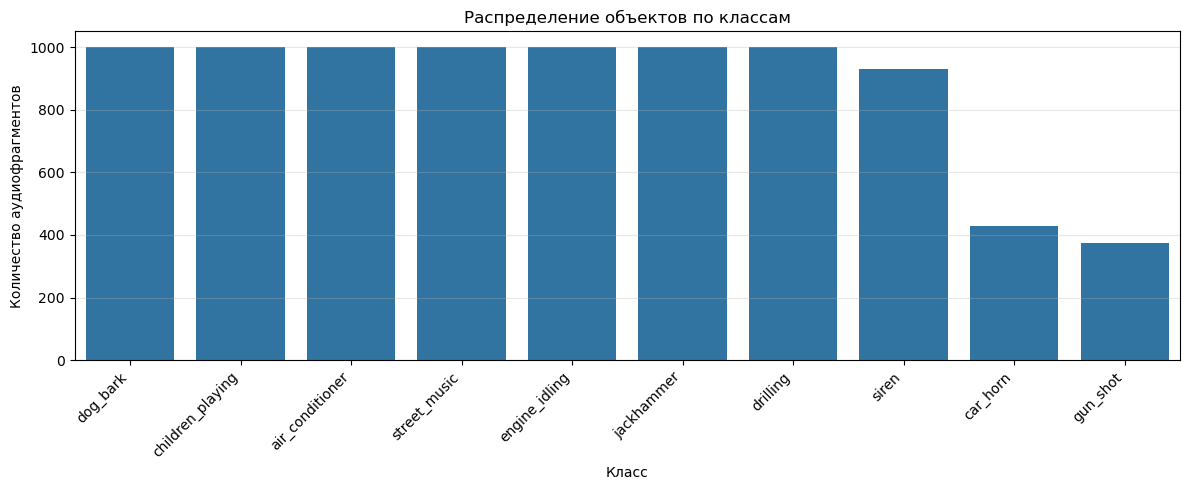

,class,count,share
0,dog_bark,1000,0.114521
1,children_playing,1000,0.114521
2,air_conditioner,1000,0.114521
3,street_music,1000,0.114521
4,engine_idling,1000,0.114521
5,jackhammer,1000,0.114521
6,drilling,1000,0.114521
7,siren,929,0.106390
8,car_horn,429,0.049130
9,gun_shot,374,0.042831


Минимальный класс: gun_shot - 374
Максимальный класс: dog_bark - 1000
Отношение max/min: 2.67


In [6]:
class_counts = (
    eda_metadata["class"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Распределение объектов по классам")
plt.xlabel("Класс")
plt.ylabel("Количество аудиофрагментов")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

class_balance = pd.DataFrame({
    "class": class_counts.index,
    "count": class_counts.values,
    "share": class_counts.values / len(eda_metadata)
})

display(class_balance)

print("Минимальный класс:", class_counts.idxmin(), "-", class_counts.min())
print("Максимальный класс:", class_counts.idxmax(), "-", class_counts.max())
print("Отношение max/min:", round(class_counts.max() / class_counts.min(), 2))


**Вывод по балансу классов.**

В датасете есть умеренный дисбаланс: часть классов представлена заметно чаще, чем другие. Поэтому одной accuracy недостаточно для анализа качества. Дополнительно нужно смотреть `macro F1`, `classification report` и confusion matrix, чтобы понять качество по каждому классу отдельно.


### Распределение по fold'ам

UrbanSound8K уже разделен на 10 официальных fold'ов. Это важно: при аудиоклассификации не стоит делать случайное разбиение строк, потому что фрагменты из одной исходной записи могут быть похожи и попасть одновременно в train и test.

Такое пересечение может привести к завышенной оценке качества.


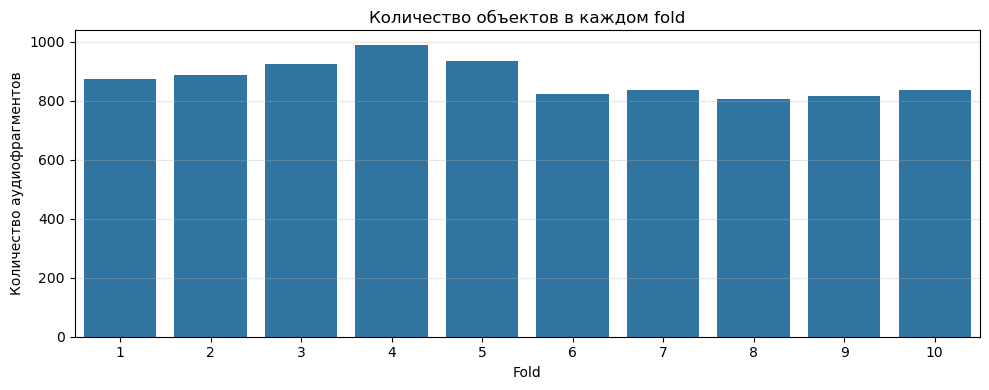

,count
fold,
1,873
2,888
3,925
4,990
5,936
6,823
7,838
8,806
9,816


In [7]:
fold_counts = eda_metadata["fold"].value_counts().sort_index()

plt.figure(figsize=(10, 4))
sns.barplot(x=fold_counts.index, y=fold_counts.values)
plt.title("Количество объектов в каждом fold")
plt.xlabel("Fold")
plt.ylabel("Количество аудиофрагментов")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

display(fold_counts.to_frame("count"))


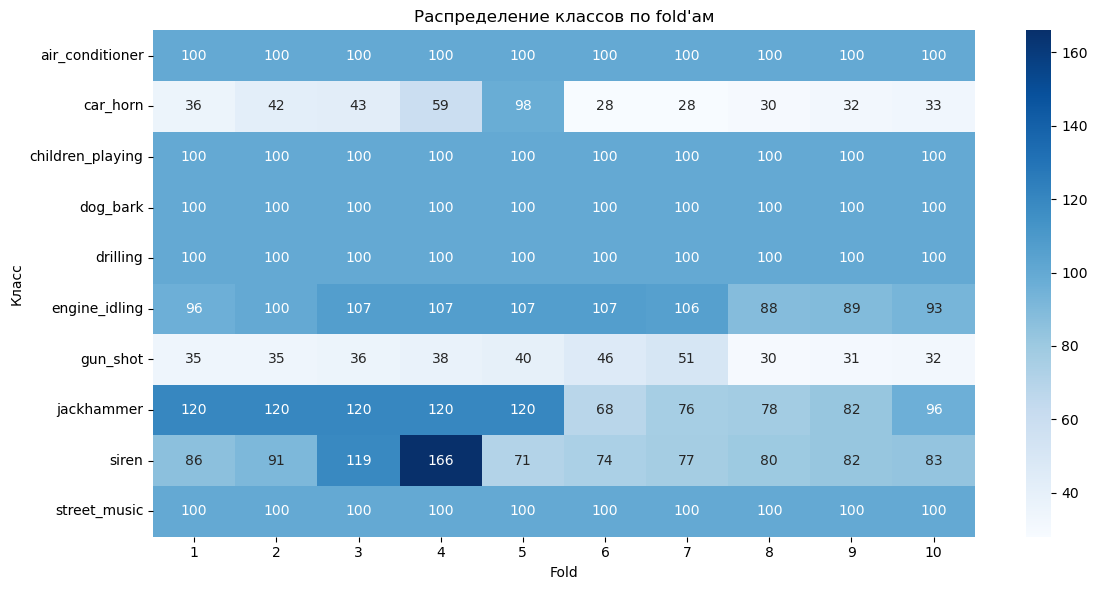

fold,1,2,3,4,5,6,7,8,9,10
class,,,,,,,,,,
air_conditioner,100,100,100,100,100,100,100,100,100,100
car_horn,36,42,43,59,98,28,28,30,32,33
children_playing,100,100,100,100,100,100,100,100,100,100
dog_bark,100,100,100,100,100,100,100,100,100,100
drilling,100,100,100,100,100,100,100,100,100,100
engine_idling,96,100,107,107,107,107,106,88,89,93
gun_shot,35,35,36,38,40,46,51,30,31,32
jackhammer,120,120,120,120,120,68,76,78,82,96
siren,86,91,119,166,71,74,77,80,82,83


In [8]:
# Распределение классов внутри fold'ов

class_fold_table = pd.crosstab(
    eda_metadata["class"],
    eda_metadata["fold"]
)

plt.figure(figsize=(12, 6))
sns.heatmap(class_fold_table, annot=True, fmt="d", cmap="Blues")
plt.title("Распределение классов по fold'ам")
plt.xlabel("Fold")
plt.ylabel("Класс")
plt.tight_layout()
plt.show()

display(class_fold_table)


**Вывод по fold'ам.**

Классы распределены по fold'ам не идеально равномерно, поэтому качество может отличаться от fold к fold. Это объясняет, почему в проекте нужна 10-fold cross-validation: один dev/test split может оказаться слишком легким или слишком сложным.


### Анализ длительности аудиофрагментов

Датасет состоит из коротких фрагментов длиной до 4 секунд. Для CNN нам нужен одинаковый размер входа, поэтому дальше в `Dataset` используется единая длина: короткие аудио дополняются нулями, длинные обрезаются.

Проверим, насколько часто встречаются короткие и длинные фрагменты.


,duration_seconds
count,8732.000000
mean,3.607904
std,0.973570
min,0.054517
1%,0.352215
5%,0.966625
25%,4.000000
50%,4.000000
75%,4.000000
95%,4.000000


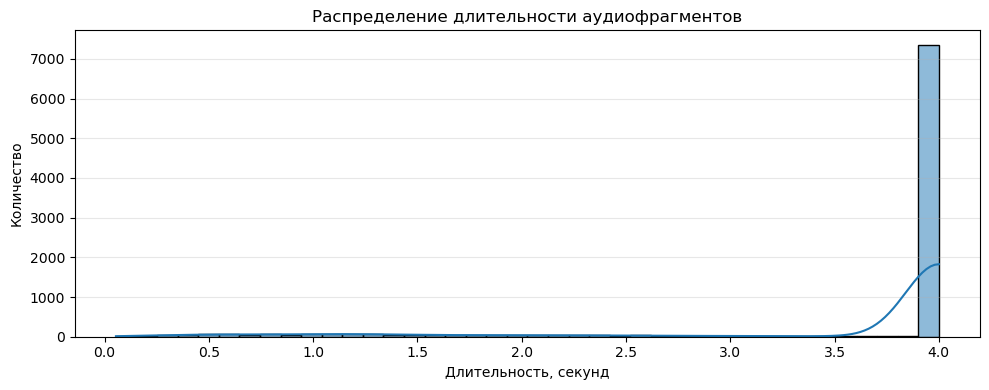

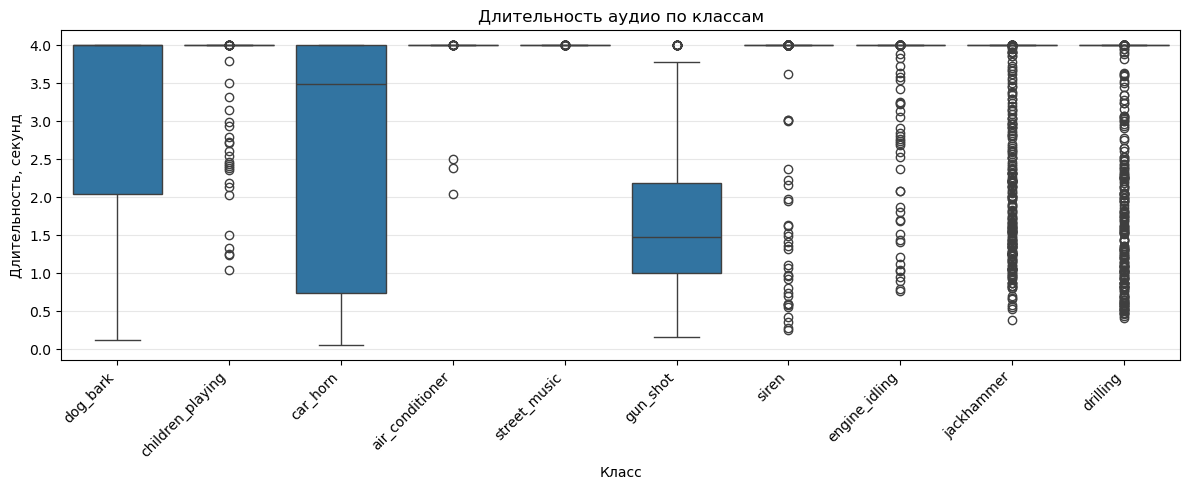

In [9]:
duration_stats = eda_metadata["duration"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
display(duration_stats.to_frame("duration_seconds"))

plt.figure(figsize=(10, 4))
sns.histplot(eda_metadata["duration"], bins=40, kde=True)
plt.title("Распределение длительности аудиофрагментов")
plt.xlabel("Длительность, секунд")
plt.ylabel("Количество")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(data=eda_metadata, x="class", y="duration")
plt.title("Длительность аудио по классам")
plt.xlabel("Класс")
plt.ylabel("Длительность, секунд")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


**Вывод по длительности.**

Фрагменты имеют разную длительность, поэтому без padding/cropping модель получала бы входы разного размера. В проекте это решается приведением каждого аудио к фиксированной длине 4 секунды. Это делает batch-обучение корректным и упрощает архитектуру CNN.


### Анализ salience

Поле `salience` показывает, насколько целевой звук является выраженным. Значение `1` обычно соответствует foreground-звуку, а `2` - background-звуку.

Это важно для модели: фоновые звуки сложнее классифицировать, потому что целевой сигнал может быть слабее или смешан с другими шумами.


salience,1,2,All
class,,,
air_conditioner,569,431,1000
car_horn,153,276,429
children_playing,588,412,1000
dog_bark,645,355,1000
drilling,902,98,1000
engine_idling,916,84,1000
gun_shot,304,70,374
jackhammer,731,269,1000
siren,269,660,929


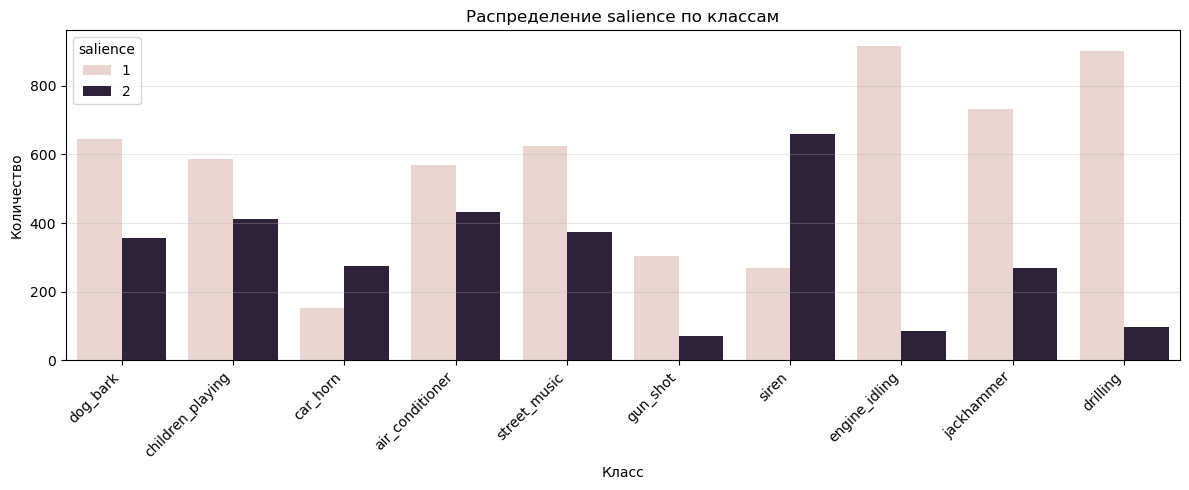

In [10]:
salience_table = pd.crosstab(
    eda_metadata["class"],
    eda_metadata["salience"],
    margins=True
)

display(salience_table)

plt.figure(figsize=(12, 5))
sns.countplot(data=eda_metadata, x="class", hue="salience")
plt.title("Распределение salience по классам")
plt.xlabel("Класс")
plt.ylabel("Количество")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Проверка исходных записей `fsID`

В аудиодатасетах важно учитывать, что несколько фрагментов могут быть нарезаны из одной исходной записи. Если случайно разделить такие похожие фрагменты между train и test, модель может получить слишком оптимистичную оценку.

Поэтому мы проверяем, сколько уникальных исходных записей есть в датасете и как они связаны с fold'ами.


Уникальных fsID: 1297
Всего фрагментов: 8732
Среднее число фрагментов на fsID: 6.73


,fragments_per_fsID
count,1297.000000
mean,6.732460
std,8.699287
min,1.000000
25%,2.000000
50%,4.000000
75%,7.000000
max,100.000000


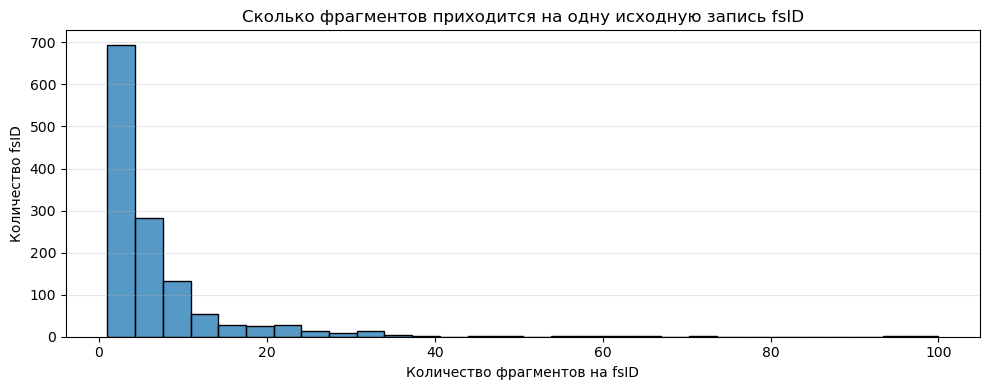

fsID, встречающиеся более чем в одном fold: 5


In [11]:
print("Уникальных fsID:", eda_metadata["fsID"].nunique())
print("Всего фрагментов:", len(eda_metadata))
print("Среднее число фрагментов на fsID:", round(len(eda_metadata) / eda_metadata["fsID"].nunique(), 2))

fsid_counts = eda_metadata["fsID"].value_counts()

display(fsid_counts.describe().to_frame("fragments_per_fsID"))

plt.figure(figsize=(10, 4))
sns.histplot(fsid_counts, bins=30)
plt.title("Сколько фрагментов приходится на одну исходную запись fsID")
plt.xlabel("Количество фрагментов на fsID")
plt.ylabel("Количество fsID")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

fsid_fold_counts = eda_metadata.groupby("fsID")["fold"].nunique()
print("fsID, встречающиеся более чем в одном fold:", (fsid_fold_counts > 1).sum())


### Визуальное сравнение классов

Для CNN мы переводим аудио в mel-спектрограмму. Это двумерное представление: по одной оси идет время, по другой - частоты, а цвет показывает энергию сигнала.

Ниже посмотрим по одному примеру каждого класса. Это помогает понять, почему CNN может работать с аудио как с изображением.


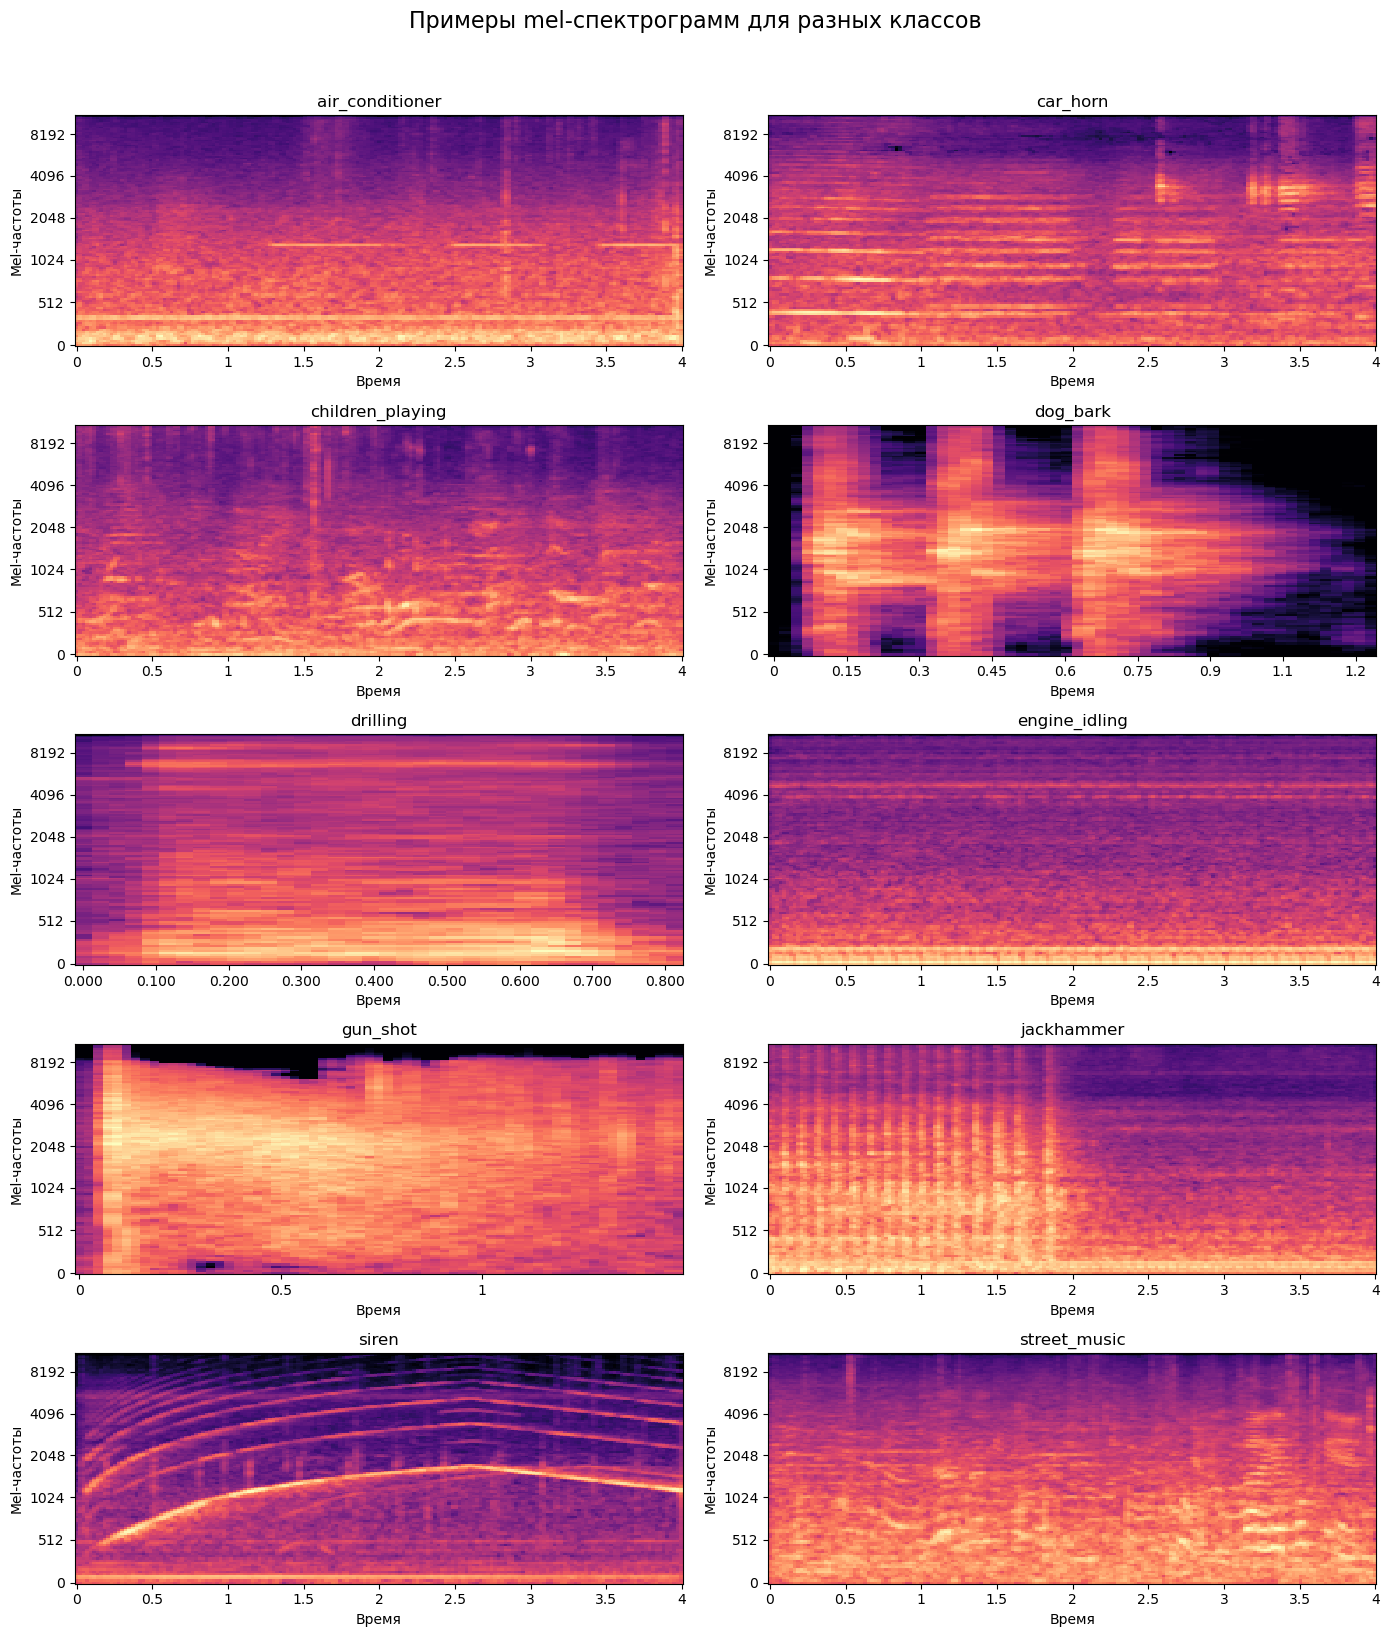

In [12]:
def plot_one_mel_per_class(metadata_df, sample_rate=22050, n_mels=128):
    classes = sorted(metadata_df["class"].unique())

    fig, axes = plt.subplots(5, 2, figsize=(14, 16))
    axes = axes.ravel()

    for ax, class_name in zip(axes, classes):
        row = metadata_df[metadata_df["class"] == class_name].sample(1, random_state=42).iloc[0]
        audio_path = row["audio_path"]

        y, sr = librosa.load(audio_path, sr=sample_rate, mono=True)

        mel = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_mels=n_mels,
            n_fft=2048,
            hop_length=512,
            power=2.0
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)

        librosa.display.specshow(
            mel_db,
            sr=sr,
            hop_length=512,
            x_axis="time",
            y_axis="mel",
            ax=ax
        )
        ax.set_title(class_name)
        ax.set_xlabel("Время")
        ax.set_ylabel("Mel-частоты")

    plt.suptitle("Примеры mel-спектрограмм для разных классов", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


if eda_metadata["file_exists"].all():
    plot_one_mel_per_class(eda_metadata)
else:
    print("Часть аудиофайлов не найдена. Проверьте DATASET_PATH.")


**Вывод по визуальному EDA.**

Разные классы имеют разные частотно-временные паттерны. Например, сирена обычно имеет выраженные полосы и периодические изменения, а звуки кондиционера или двигателя часто выглядят как более ровный шум. Поэтому mel-спектрограммы являются разумным входом для CNN.


### Быстрая проверка параметров аудио на подвыборке

Полный проход по всем аудиофайлам может занимать время, поэтому для EDA достаточно проверить случайную подвыборку. Смотрим реальные sample rate, длительность после загрузки и простые характеристики амплитуды.


/var/folders/z0/r9mzz2td5r7csldbwymqzs000000gn/T/ipykernel_79107/2530692057.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 5), random_state=42))


Audio sample EDA:   0%|          | 0/50 [00:00<?, ?it/s]

,class,file,native_sr,real_duration,mean_abs_amplitude,max_abs_amplitude,rms
0,air_conditioner,184805-0-0-104.wav,44100,4.0,0.009586,0.079987,0.012047
1,air_conditioner,47160-0-0-3.wav,48000,4.0,0.140853,0.921127,0.177342
2,air_conditioner,50901-0-1-0.wav,44100,4.0,0.056454,0.949982,0.076986
3,air_conditioner,195969-0-0-22.wav,48000,4.0,0.006365,0.037533,0.007989
4,air_conditioner,177726-0-0-28.wav,48000,4.0,0.011548,0.057930,0.014271


Sample rate на подвыборке:


,count
native_sr,
44100,30
48000,17
16000,2
96000,1


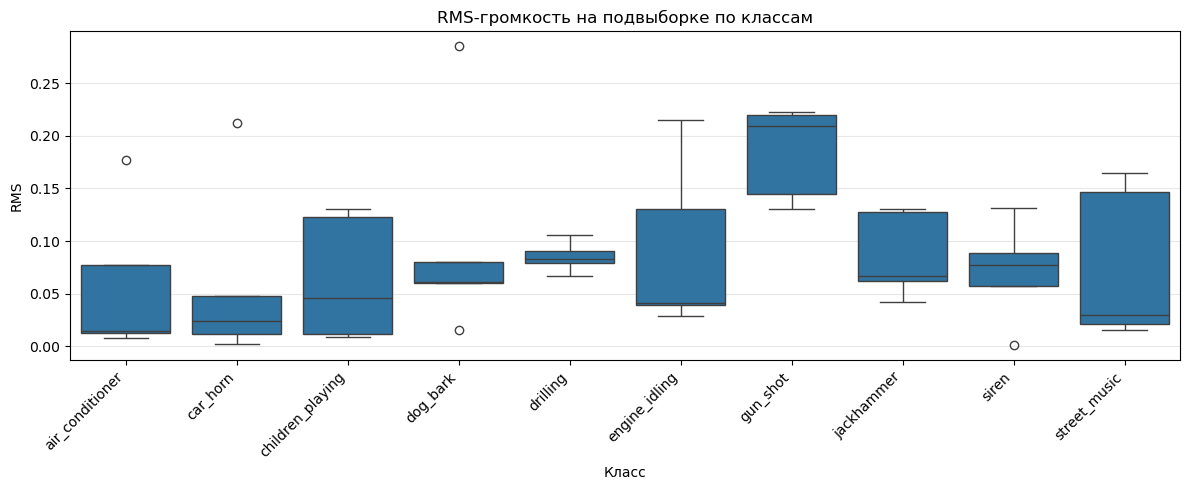

In [14]:
sample_audio_df = (
    eda_metadata
    .groupby("class", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), 5), random_state=42))
    .reset_index(drop=True)
)

audio_stats = []

for _, row in tqdm(sample_audio_df.iterrows(), total=len(sample_audio_df), desc="Audio sample EDA"):
    audio_path = row["audio_path"]

    try:
        y_native, sr_native = librosa.load(audio_path, sr=None, mono=True)
        duration_native = len(y_native) / sr_native

        audio_stats.append({
            "class": row["class"],
            "file": row["slice_file_name"],
            "native_sr": sr_native,
            "real_duration": duration_native,
            "mean_abs_amplitude": float(np.mean(np.abs(y_native))),
            "max_abs_amplitude": float(np.max(np.abs(y_native))),
            "rms": float(np.sqrt(np.mean(y_native ** 2))),
        })
    except Exception as e:
        audio_stats.append({
            "class": row["class"],
            "file": row["slice_file_name"],
            "native_sr": None,
            "real_duration": None,
            "mean_abs_amplitude": None,
            "max_abs_amplitude": None,
            "rms": None,
        })

audio_stats_df = pd.DataFrame(audio_stats)
display(audio_stats_df.head())

print("Sample rate на подвыборке:")
display(audio_stats_df["native_sr"].value_counts(dropna=False).to_frame("count"))

plt.figure(figsize=(12, 5))
sns.boxplot(data=audio_stats_df, x="class", y="rms")
plt.title("RMS-громкость на подвыборке по классам")
plt.xlabel("Класс")
plt.ylabel("RMS")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Итоговые выводы EDA

1. В датасете 10 классов городских звуков, задача является многоклассовой классификацией.
2. Классы представлены не идеально равномерно, поэтому кроме accuracy нужно смотреть `macro F1` и ошибки по классам.
3. UrbanSound8K уже имеет официальные 10 fold'ов, поэтому для честной оценки используется fold-aware split и 10-fold cross-validation.
4. Аудиофрагменты имеют разную длительность, поэтому перед обучением их нужно приводить к одной длине.
5. Mel-спектрограмма является удобным входом для CNN, потому что переводит аудио в частотно-временное двумерное представление.
6. Часть классов визуально и акустически похожи, поэтому confusion matrix нужна не только для оценки, но и для интерпретации ошибок модели.

После EDA переходим к предобработке: кодируем метки, приводим аудио к фиксированной длине, строим mel-спектрограммы и формируем `Dataset` для PyTorch.


Сначала посмотрим, как выглядят один и тот же аудиофрагмент в виде волновой формы, обычной спектрограммы и мел-спектрограммы.

Sample: 145683-6-2-0.wav
Class: gun_shot
Fold: 9
Path: /Users/polzovatel/.cache/kagglehub/datasets/chrisfilo/urbansound8k/versions/1/fold9/145683-6-2-0.wav
File exists: True



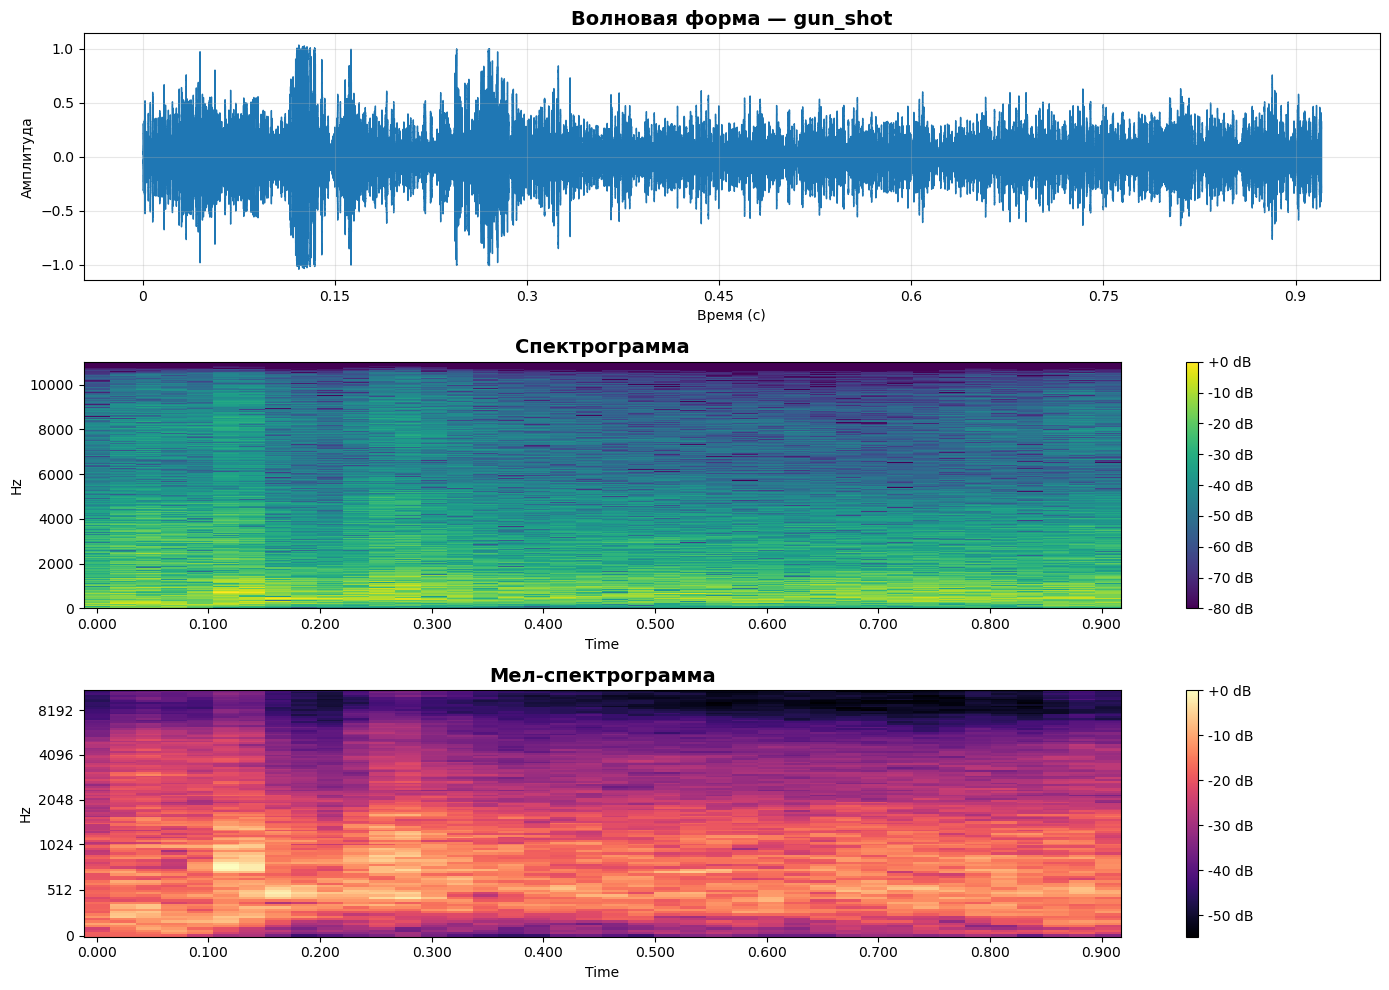

In [15]:
def plot_waveform_and_spectrogram(audio_path, class_name):
    y, sr = librosa.load(audio_path, sr=22050)

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    librosa.display.waveshow(y, sr=sr, ax=axes[0])
    axes[0].set_title(f"Волновая форма — {class_name}", fontsize=14, fontweight="bold")
    axes[0].set_xlabel("Время (с)")
    axes[0].set_ylabel("Амплитуда")
    axes[0].grid(alpha=0.3)

    D = librosa.stft(y)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    img1 = librosa.display.specshow(
        S_db, sr=sr, x_axis="time", y_axis="hz", ax=axes[1], cmap="viridis"
    )
    axes[1].set_title("Спектрограмма", fontsize=14, fontweight="bold")
    fig.colorbar(img1, ax=axes[1], format="%+2.0f dB")

    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    img2 = librosa.display.specshow(
        mel_spec_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[2], cmap="magma"
    )
    axes[2].set_title("Мел-спектрограмма", fontsize=14, fontweight="bold")
    fig.colorbar(img2, ax=axes[2], format="%+2.0f dB")

    plt.tight_layout()
    plt.show()
    return y, sr


random_idx = np.random.randint(0, len(eda_metadata))
sample = eda_metadata.iloc[random_idx]

audio_path = sample["audio_path"]

print(f"Sample: {sample.slice_file_name}")
print(f"Class: {sample['class']}")
print(f"Fold: {sample.fold}")
print(f"Path: {audio_path}")
print(f"File exists: {os.path.exists(audio_path)}\n")

y, sr = plot_waveform_and_spectrogram(audio_path, sample["class"])
Audio(y, rate=sr)
Audio(y, rate=sr)

Sample: 208030-3-2-0.wav
Class: dog_bark
Fold: 6
Path: /Users/polzovatel/.cache/kagglehub/datasets/chrisfilo/urbansound8k/versions/1/fold6/208030-3-2-0.wav
File exists: True


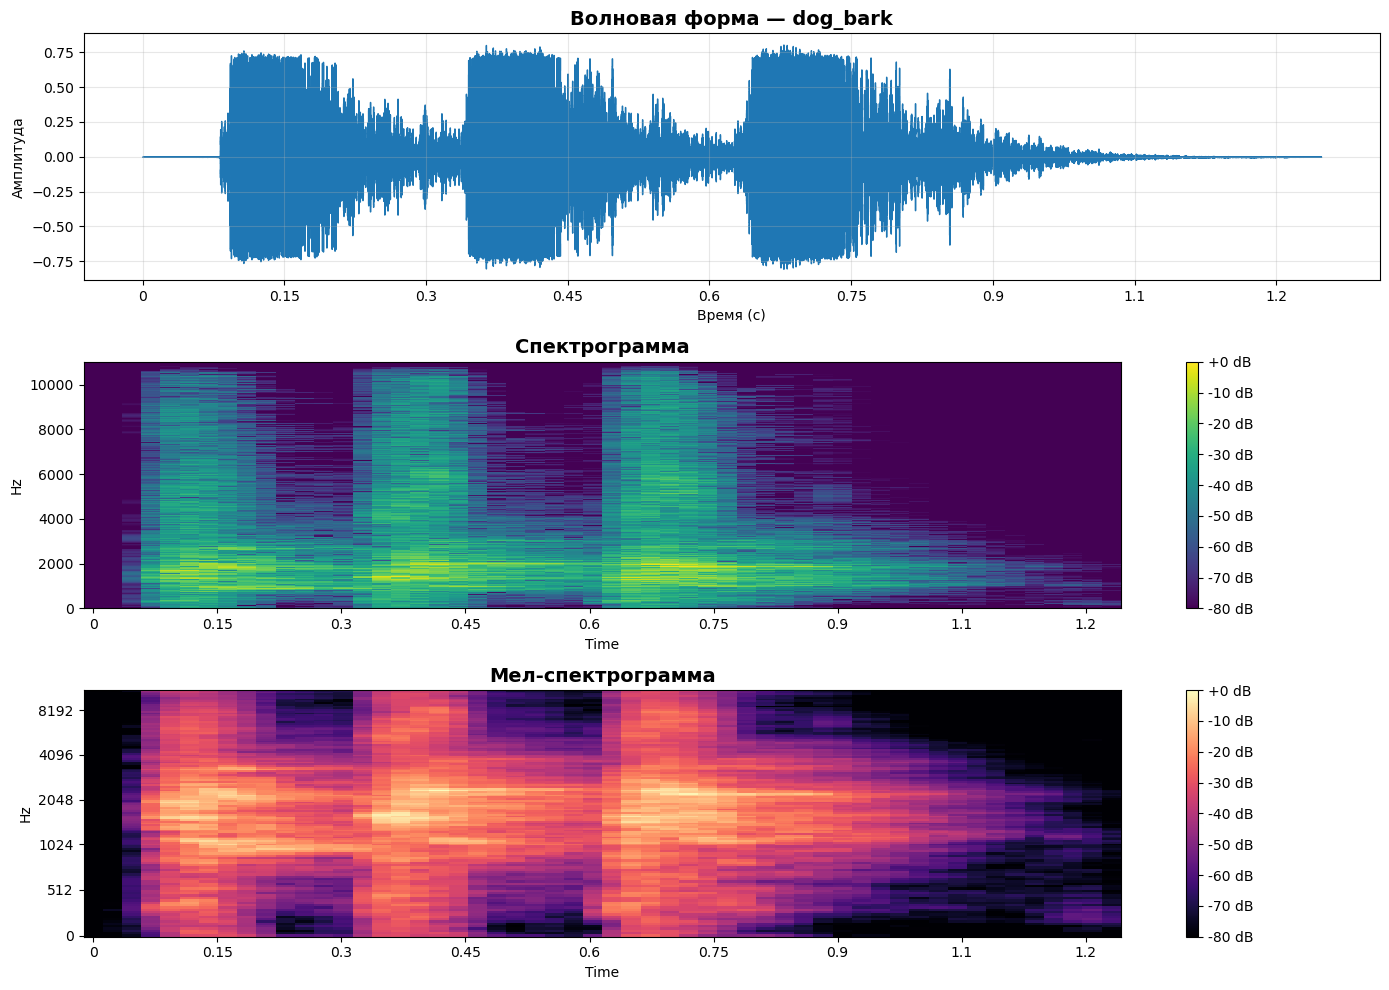

In [16]:
target_class = "dog_bark"

class_samples = eda_metadata[
    (eda_metadata["class"] == target_class) &
    (eda_metadata["file_exists"])
].copy()

if len(class_samples) == 0:
    raise ValueError(f"Для класса {target_class} не найдено доступных аудиофайлов")

sample = class_samples.sample(1, random_state=42).iloc[0]

audio_path = sample["audio_path"]

print(f"Sample: {sample['slice_file_name']}")
print(f"Class: {sample['class']}")
print(f"Fold: {sample['fold']}")
print(f"Path: {audio_path}")
print(f"File exists: {os.path.exists(audio_path)}")

y, sr = plot_waveform_and_spectrogram(audio_path, target_class)

Audio(y, rate=sr)